In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "Ride_ID": np.arange(1001, 1001+n),
    "Date": pd.date_range(start="2025-01-01", periods=n, freq='h'),
    "City": np.random.choice(['Ahmedabad','Surat','Rajkot','Vadodara', None], n),
    "Pickup_Area": np.random.choice(['Area A','Area B','Area C','Area D'], n),
    "Drop_Area": np.random.choice(['Area X','Area Y','Area Z'], n),
    "Customer_Age": np.random.randint(18, 60, n),
    "Customer_Gender": np.random.choice(['Male','Female'], n),
    "Vehicle_Type": np.random.choice(['Bike','Auto','bike','AUTO'], n),
    "Ride_Distance_KM": np.random.uniform(1, 20, n),
    "Ride_Duration_Min": np.random.uniform(5, 60, n),
    "Fare_Amount": np.random.uniform(30, 300, n),
    "Surge_Multiplier": np.random.choice([1,1.5,2], n),
    "Payment_Mode": np.random.choice(['UPI','Cash','Card','upi','cash', None], n),
    "Driver_Rating": np.random.uniform(2, 5, n),
    "Ride_Status": np.random.choice(['Completed','Cancelled','No Show'], n),
    "Time_Of_Day": np.random.choice(['Morning','Afternoon','Evening','Night'], n)
}

df = pd.DataFrame(data)

for col in ['Fare_Amount','Driver_Rating','Ride_Distance_KM']:
    df.loc[np.random.choice(df.index, 10), col] = np.nan

df = pd.concat([df, df.iloc[:5]])

df.loc[0, 'Fare_Amount'] = 1000
df.loc[1, 'Ride_Distance_KM'] = 100
df.loc[2, 'Ride_Duration_Min'] = 200

df.to_csv("rapido_rides.csv", index=False)

df.head()

,Ride_ID,Date,City,Pickup_Area,Drop_Area,Customer_Age,Customer_Gender,Vehicle_Type,Ride_Distance_KM,Ride_Duration_Min,Fare_Amount,Surge_Multiplier,Payment_Mode,Driver_Rating,Ride_Status,Time_Of_Day
0,1001,2025-01-01 00:00:00,Vadodara,Area B,Area Z,30,Male,Auto,7.323500,32.185062,1000.000000,1.0,NaN,2.692488,Cancelled,Night
1,1002,2025-01-01 01:00:00,NaN,Area B,Area Y,40,Female,Auto,100.000000,36.531191,NaN,1.5,NaN,3.370576,Cancelled,Morning
2,1003,2025-01-01 02:00:00,Rajkot,Area B,Area Z,42,Female,bike,14.180635,200.000000,58.575205,1.0,UPI,2.570975,No Show,Evening
3,1004,2025-01-01 03:00:00,NaN,Area C,Area Z,52,Male,AUTO,4.167884,27.240983,218.727499,1.5,cash,2.157017,Completed,Night
4,1005,2025-01-01 04:00:00,NaN,Area C,Area Y,58,Female,AUTO,17.693953,47.400126,NaN,1.5,UPI,3.135429,No Show,Evening


In [3]:
import pandas as pd

df = pd.read_csv("rapido_rides.csv")

df.head(), df.tail(), df.shape, df.columns, df.info(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ride_ID            205 non-null    int64  
 1   Date               205 non-null    str    
 2   City               166 non-null    str    
 3   Pickup_Area        205 non-null    str    
 4   Drop_Area          205 non-null    str    
 5   Customer_Age       205 non-null    int64  
 6   Customer_Gender    205 non-null    str    
 7   Vehicle_Type       205 non-null    str    
 8   Ride_Distance_KM   196 non-null    float64
 9   Ride_Duration_Min  205 non-null    float64
 10  Fare_Amount        194 non-null    float64
 11  Surge_Multiplier   205 non-null    float64
 12  Payment_Mode       174 non-null    str    
 13  Driver_Rating      195 non-null    float64
 14  Ride_Status        205 non-null    str    
 15  Time_Of_Day        205 non-null    str    
dtypes: float64(5), int64(2), str(9)
memor

(   Ride_ID                 Date      City Pickup_Area Drop_Area  Customer_Age  \
 0     1001  2025-01-01 00:00:00  Vadodara      Area B    Area Z            30   
 1     1002  2025-01-01 01:00:00       NaN      Area B    Area Y            40   
 2     1003  2025-01-01 02:00:00    Rajkot      Area B    Area Z            42   
 3     1004  2025-01-01 03:00:00       NaN      Area C    Area Z            52   
 4     1005  2025-01-01 04:00:00       NaN      Area C    Area Y            58   
 
   Customer_Gender Vehicle_Type  Ride_Distance_KM  Ride_Duration_Min  \
 0            Male         Auto          7.323500          32.185062   
 1          Female         Auto        100.000000          36.531191   
 2          Female         bike         14.180635         200.000000   
 3            Male         AUTO          4.167884          27.240983   
 4          Female         AUTO         17.693953          47.400126   
 
    Fare_Amount  Surge_Multiplier Payment_Mode  Driver_Rating Ride_Statu

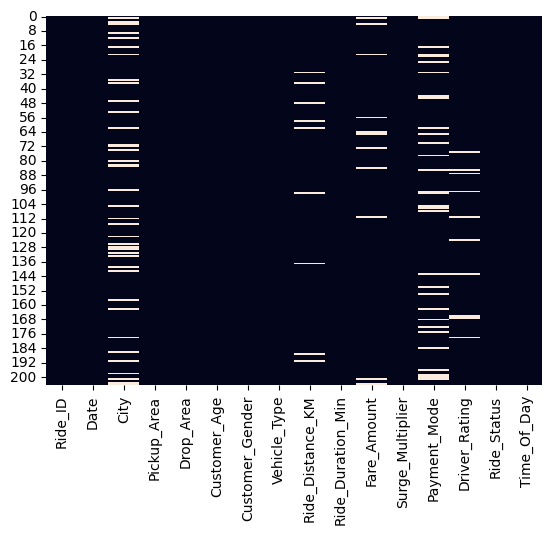

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df.isnull().sum()

sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [7]:
df['Fare_Amount'].fillna(df['Fare_Amount'].median(), inplace=True)
df['Driver_Rating'].fillna(df['Driver_Rating'].mean(), inplace=True)
df['Ride_Distance_KM'].fillna(df['Ride_Distance_KM'].median(), inplace=True)
df['Ride_Duration_Min'].fillna(df['Ride_Duration_Min'].median(), inplace=True)

df['Payment_Mode'].fillna(df['Payment_Mode'].mode()[0], inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)
df['Vehicle_Type'].fillna(df['Vehicle_Type'].mode()[0], inplace=True)

df.isnull().sum()

C:\Users\Devarsh\AppData\Local\Temp\ipykernel_21196\2922119737.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Fare_Amount'].fillna(df['Fare_Amount'].median(), inplace=True)
C:\Users\Devarsh\AppData\Local\Temp\ipykernel_21196\2922119737.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

Ride_ID               0
Date                  0
City                 39
Pickup_Area           0
Drop_Area             0
Customer_Age          0
Customer_Gender       0
Vehicle_Type          0
Ride_Distance_KM      9
Ride_Duration_Min     0
Fare_Amount          11
Surge_Multiplier      0
Payment_Mode         31
Driver_Rating        10
Ride_Status           0
Time_Of_Day           0
dtype: int64

In [8]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

df.shape

(200, 16)

In [9]:
df['Payment_Mode'] = df['Payment_Mode'].str.lower()
df['Vehicle_Type'] = df['Vehicle_Type'].str.lower()
df['City'] = df['City'].str.lower()

df['Payment_Mode'] = df['Payment_Mode'].replace({
    'upi': 'UPI',
    'cash': 'Cash',
    'card': 'Card',
    'wallet': 'Wallet'
})

df.head()

,Ride_ID,Date,City,Pickup_Area,Drop_Area,Customer_Age,Customer_Gender,Vehicle_Type,Ride_Distance_KM,Ride_Duration_Min,Fare_Amount,Surge_Multiplier,Payment_Mode,Driver_Rating,Ride_Status,Time_Of_Day
0,1001,2025-01-01 00:00:00,vadodara,Area B,Area Z,30,Male,auto,7.323500,32.185062,1000.000000,1.0,NaN,2.692488,Cancelled,Night
1,1002,2025-01-01 01:00:00,NaN,Area B,Area Y,40,Female,auto,100.000000,36.531191,NaN,1.5,NaN,3.370576,Cancelled,Morning
2,1003,2025-01-01 02:00:00,rajkot,Area B,Area Z,42,Female,bike,14.180635,200.000000,58.575205,1.0,UPI,2.570975,No Show,Evening
3,1004,2025-01-01 03:00:00,NaN,Area C,Area Z,52,Male,auto,4.167884,27.240983,218.727499,1.5,Cash,2.157017,Completed,Night
4,1005,2025-01-01 04:00:00,NaN,Area C,Area Y,58,Female,auto,17.693953,47.400126,NaN,1.5,UPI,3.135429,No Show,Evening


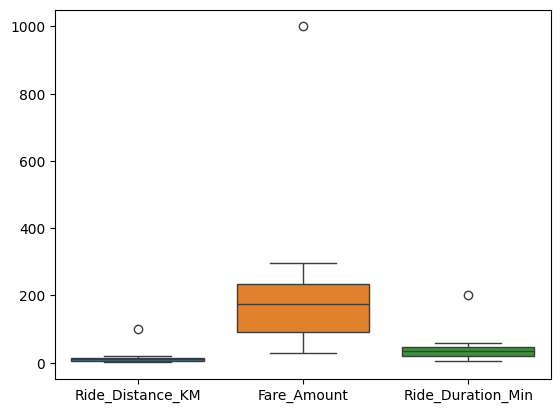

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['Ride_Distance_KM','Fare_Amount','Ride_Duration_Min']])
plt.show()

In [11]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['Fare_Amount','Ride_Distance_KM','Ride_Duration_Min']:
    df = remove_outliers(df, col)

df.shape

(180, 16)

In [4]:
import pandas as pd

df = pd.read_csv("rapido_ride_dataset.csv")

num_cols = ["Ride_Distance_KM", "Fare_Amount", "Ride_Duration_Min"]

for col in num_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

print(df[num_cols].head())


FileNotFoundError: [Errno 2] No such file or directory: 'rapido_ride_dataset.csv'

In [13]:
df = pd.get_dummies(df, columns=['City','Payment_Mode','Vehicle_Type','Ride_Status'], drop_first=True)

df.head()

,Ride_ID,Date,Pickup_Area,Drop_Area,Customer_Age,Customer_Gender,Ride_Distance_KM,Ride_Duration_Min,Fare_Amount,Surge_Multiplier,Driver_Rating,Time_Of_Day,City_rajkot,City_surat,City_vadodara,Payment_Mode_Cash,Payment_Mode_UPI,Vehicle_Type_bike,Ride_Status_Completed,Ride_Status_No Show
3,1004,2025-01-01 03:00:00,Area C,Area Z,52,Male,4.167884,27.240983,218.727499,1.5,2.157017,Night,False,False,False,True,False,False,True,False
5,1006,2025-01-01 05:00:00,Area D,Area Y,47,Female,10.413049,28.211983,268.042026,2.0,3.088833,Evening,False,True,False,False,True,True,True,False
6,1007,2025-01-01 06:00:00,Area D,Area Y,34,Male,15.087757,24.462926,289.555128,1.5,4.986441,Evening,True,False,False,True,False,False,True,False
7,1008,2025-01-01 07:00:00,Area A,Area X,37,Male,11.889866,57.724495,155.676902,1.5,3.339057,Morning,True,False,False,True,False,True,False,False
8,1009,2025-01-01 08:00:00,Area A,Area X,42,Male,19.956160,15.140401,267.349300,2.0,3.000709,Night,True,False,False,False,False,False,False,True


In [14]:
df['Fare_per_KM'] = df['Fare_Amount'] / (df['Ride_Distance_KM'] + 1e-5)
df['Ride_Speed'] = df['Ride_Distance_KM'] / (df['Ride_Duration_Min'] + 1e-5)

df['Peak_Ride'] = df['Time_Of_Day'].apply(lambda x: 1 if x in ['Evening','Night'] else 0)

df.head()

,Ride_ID,Date,Pickup_Area,Drop_Area,Customer_Age,Customer_Gender,Ride_Distance_KM,Ride_Duration_Min,Fare_Amount,Surge_Multiplier,...,City_surat,City_vadodara,Payment_Mode_Cash,Payment_Mode_UPI,Vehicle_Type_bike,Ride_Status_Completed,Ride_Status_No Show,Fare_per_KM,Ride_Speed,Peak_Ride
3,1004,2025-01-01 03:00:00,Area C,Area Z,52,Male,4.167884,27.240983,218.727499,1.5,...,False,False,True,False,False,True,False,52.479136,0.153000,1
5,1006,2025-01-01 05:00:00,Area D,Area Y,47,Female,10.413049,28.211983,268.042026,2.0,...,True,False,False,True,True,True,False,25.740950,0.369100,1
6,1007,2025-01-01 06:00:00,Area D,Area Y,34,Male,15.087757,24.462926,289.555128,1.5,...,False,False,True,False,False,True,False,19.191383,0.616760,1
7,1008,2025-01-01 07:00:00,Area A,Area X,37,Male,11.889866,57.724495,155.676902,1.5,...,False,False,True,False,True,False,False,13.093232,0.205976,0
8,1009,2025-01-01 08:00:00,Area A,Area X,42,Male,19.956160,15.140401,267.349300,2.0,...,False,False,False,False,False,False,True,13.396824,1.318073,1


In [15]:
df['Fare_Amount'].mean()

df['Driver_Rating'].mean()

df.filter(like='Payment_Mode').sum()

df.groupby('Time_Of_Day')['Ride_Distance_KM'].mean()

Time_Of_Day
Afternoon    10.506905
Evening      10.286530
Morning      10.770338
Night        11.858763
Name: Ride_Distance_KM, dtype: float64

In [16]:
df.to_csv("cleaned_rapido_data.csv", index=False)